# 03 - The Correct Pipeline (No Leakage)

Same experiment as notebook 02, same models, same split ratios, same
number of rounds. The **only** difference is the order of operations:

1. **Split** into train/test first.
2. **Then** duplicate only the training half.

The test set is always untouched, original, unseen data, so there is no
way for a duplicate row to leak into it.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from cancer_ml_leakage_demo.data import load_data
from cancer_ml_leakage_demo.leakage import correct_split
from cancer_ml_leakage_demo.metrics import run_experiment, summarize

X, y = load_data()

## Run The Experiment
Same as the paper but for correctly splitted dateset: try every split ratio (50-50, 60-40, 70-30, 80-20),
repeat each one 100 times with a different random split, and record every
model's accuracy each time.

In [2]:
SPLIT_RATIOS = {
    "50-50": 0.5,
    "60-40": 0.4,
    "70-30": 0.3,
    "80-20": 0.2,
}
N_ROUNDS = 100

correct_summaries = []
for split_name, test_size in SPLIT_RATIOS.items():
    results = run_experiment(X, y, split_fn = correct_split, test_size = test_size, n_rounds = N_ROUNDS)
    summary = summarize(results)
    summary.insert(0, "split", split_name)
    correct_summaries.append(summary)
    print(f"done: {split_name} split")

correct_summary = pd.concat(correct_summaries, ignore_index=True)
correct_summary

done: 50-50 split


R:\My Projects\cancer_ml_leakage_demo\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


done: 60-40 split
done: 70-30 split
done: 80-20 split


,split,model,mean_accuracy,max_accuracy,min_accuracy
0,50-50,Random Forest,0.958386,0.985965,0.926316
1,50-50,Logistic Regression,0.949860,0.975439,0.919298
2,50-50,Naive Bayes,0.938982,0.961404,0.912281
3,50-50,Neural Network,0.935228,0.978947,0.887719
4,50-50,Decision Tree,0.928175,0.954386,0.891228
5,50-50,Nearest Neighbor,0.924000,0.950877,0.870175
6,50-50,SVM,0.916351,0.943860,0.880702
7,60-40,Random Forest,0.959605,0.986842,0.925439
8,60-40,Logistic Regression,0.950132,0.973684,0.912281
9,60-40,Naive Bayes,0.938289,0.960526,0.912281


## Save The Results
Saved so `max_vs_min_accuracy.ipynb` can load it back in and compare against the correct pipeline.

In [3]:
correct_summary.to_csv("../results/tables/correct_summary.csv", index = False)
print("saved to results/tables/correct_summary.csv")

saved to results/tables/correct_summary.csv


## Does Any Model Hit 100% Accuracy

In [4]:
perfect = correct_summary[correct_summary["max_accuracy"] >= 0.999]
print(f"{len(perfect)} (split, model) combinations reached ~100% best-case accuracy.")
perfect[["split", "model", "max_accuracy"]]

2 (split, model) combinations reached ~100% best-case accuracy.


,split,model,max_accuracy
21,80-20,Random Forest,1.0
22,80-20,Logistic Regression,1.0


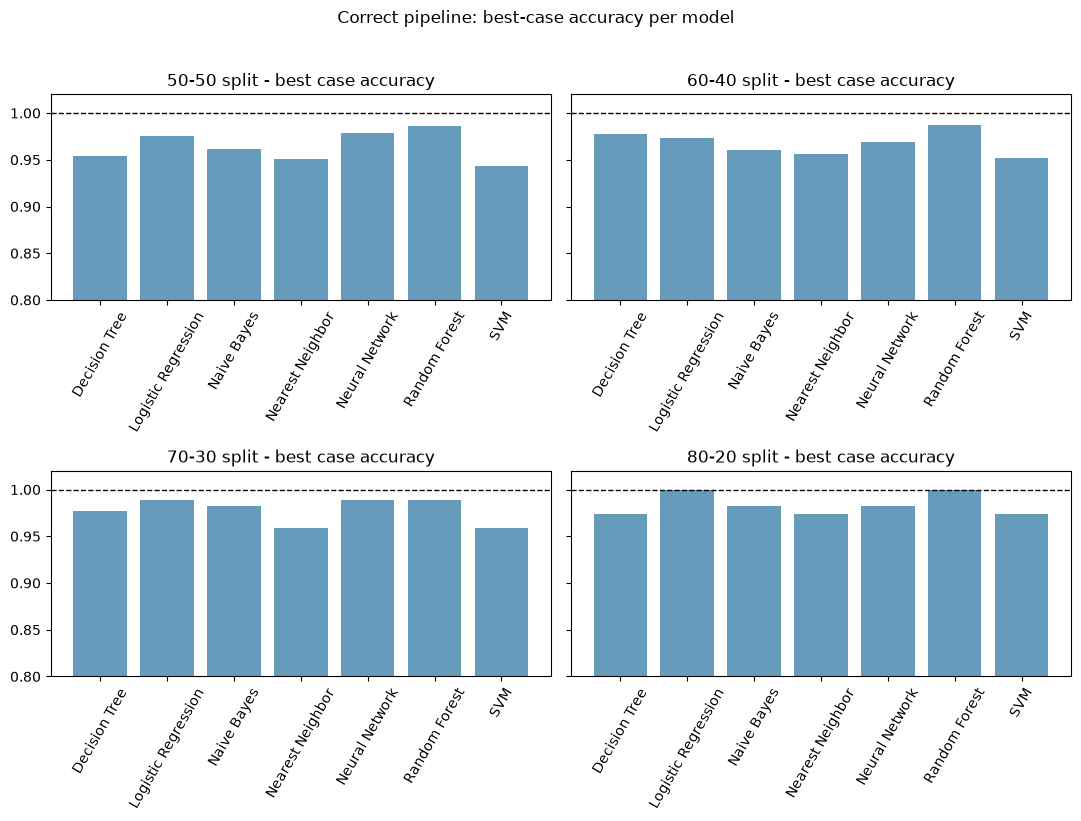

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)

for ax, (split_name, _) in zip(axes.flat, SPLIT_RATIOS.items()):
    subset = correct_summary[correct_summary["split"] == split_name].sort_values("model")
    ax.bar(subset["model"], subset["max_accuracy"], color = "#669BBC")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{split_name} split - best case accuracy")
    ax.set_ylim(0.8, 1.02)
    ax.tick_params(axis="x", rotation=60)

fig.suptitle("Correct pipeline: best-case accuracy per model", y=1.02)
fig.tight_layout()
fig.savefig("../results/figures/03_correct_max_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## Observation
Best-case accuracy is lower overall, and it no longer hits 100% *systematically* the way Random Forest and Decision Tree did in the leaky pipeline (5 out of 28 split/model combinations there). Here it only happens twice, both on the smallest test set (80-20 split, ~114 test rows) - a small test set can occasionally be guessed perfectly by chance on an easy, well-separated dataset like this one, with no leakage involved. That's a very different, far less alarming story than a model hitting 100% because it was tested on rows it had already memorised.